<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install pyspark

In [59]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [60]:
# Initialize Spark with optimizations for large data
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
file_path = '/content/drive/MyDrive/CSV/Trade_CropsLivestock_E_All_Data_(Normalized).csv'

df = spark.read.csv(file_path, header=True, inferSchema=True)

In [63]:
df_before = df  # This is just a reference, not a copy

In [64]:
# Cache the dataframe to avoid recomputation
df.cache()

total_records = df.count()
print(f"Total records: {total_records:,}")
print(f"Total columns: {len(df.columns)}")

Total records: 17,270,631
Total columns: 14


In [65]:
print("\n--- Dataset Overview (BEFORE) ---")
# Check rows with missing values BEFORE
print("\n--- Rows with Missing Values (BEFORE) ---")

# Count rows that have ANY missing value
rows_with_missing = df.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df.columns]) == 1
).count()

rows_complete = total_records - rows_with_missing
print(f"  Complete rows (no missing): {rows_complete:,} ({rows_complete/total_records*100:.2f}%)")
print(f"  Rows with missing values: {rows_with_missing:,} ({rows_with_missing/total_records*100:.2f}%)")


--- Dataset Overview (BEFORE) ---

--- Rows with Missing Values (BEFORE) ---
  Complete rows (no missing): 952,262 (5.51%)
  Rows with missing values: 16,318,369 (94.49%)


In [66]:
# Get year range
min_year = df.select(F.min('Year')).collect()[0][0]
max_year = df.select(F.max('Year')).collect()[0][0]
print(f"Year range: {min_year} - {max_year}")

Year range: 1961 - 2024


In [68]:
# Check duplicates BEFORE
print("\n--- Duplicate Records (BEFORE) ---")
duplicates_before = total_records - df.distinct().count()
print(f"Duplicate rows: {duplicates_before:,}")


--- Duplicate Records (BEFORE) ---
Duplicate rows: 0


In [71]:
# EDA 1: TRADE ITEMS FOR EACH CATEGORY
print("\n" + "=" * 80)
print("EDA 1: TRADE ITEMS FOR EACH CATEGORY")
print("=" * 80)

# Define all categories based on your dataset description
crops_primary = ["Cereals", "Citrus Fruit", "Fibre Crops", "Fruit", "Oil Crops",
                 "Pulses", "Roots and Tubers", "Sugar Crops", "Treenuts", "Vegetables",
                 "Wheat", "Rice", "Maize", "Barley", "Sorghum", "Rye", "Oats", "Millet"]

crops_processed = ["Beer of barley", "Cotton lint", "Cottonseed", "Margarine, short",
                   "Molasses", "Oil, coconut (copra)", "Oil, cottonseed", "Oil, groundnut",
                   "Oil, linseed", "Oil, maize", "Oil, olive, virgin", "Oil, palm",
                   "Oil, palm kernel", "Oil, rapeseed", "Oil, safflower", "Oil, sesame",
                   "Oil, soybean", "Oil, sunflower", "Palm kernels", "Sugar Raw Centrifugal", "Wine"]

livestock_primary = ["Beeswax", "Eggs", "Hides", "Honey", "Meat", "Milk", "Offals",
                     "Silk-worm cocoons", "Skins", "Snails", "Wool", "Live animals",
                     "Cattle", "Pigs", "Sheep", "Goats", "Chickens", "Buffaloes", "Camels"]

livestock_processed = ["Butter", "Cheese", "Cream fresh", "Ghee", "Lard",
                       "Milk (dry buttermilk", "Milk (skimmed", "Milk (whole",
                       "Silk raw", "Tallow", "Whey", "Yoghurt"]

# Create category column
df_categorized = df_before.withColumn(
    "Trade_Category",
    F.when(F.col("Item").isin(crops_primary), "🌾 Crops (Primary)")
     .when(F.col("Item").isin(crops_processed), "🏭 Crops (Processed)")
     .when(F.col("Item").isin(livestock_primary), "🐄 Livestock (Primary)")
     .when(F.col("Item").isin(livestock_processed), "🧀 Livestock (Processed)")
     .otherwise("📦 Other")
)

# 1. CROPS PRIMARY - Top items
print("\n" + "=" * 60)
print("🌾 CROPS (PRIMARY) - Top Trade Items")
print("=" * 60)

crops_primary_items = df_categorized.filter(F.col("Trade_Category") == "🌾 Crops (Primary)") \
    .groupBy("Item") \
    .agg(
        F.count("*").alias("Record_Count"),
        F.sum("Value").alias("Total_Value"),
        F.avg("Value").alias("Avg_Value")
    ) \
    .orderBy(F.desc("Record_Count"))

print(f"\nTotal distinct primary crop items: {crops_primary_items.count():,}")
print(f"Total records: {crops_primary_items.agg(F.sum('Record_Count')).collect()[0][0]:,}")
print("\nTop 10 Primary Crop Items:")
crops_primary_items.show(10, truncate=False)

# 2. CROPS PROCESSED - Top items
print("\n" + "=" * 60)
print("🏭 CROPS (PROCESSED) - Top Trade Items")
print("=" * 60)

crops_processed_items = df_categorized.filter(F.col("Trade_Category") == "🏭 Crops (Processed)") \
    .groupBy("Item") \
    .agg(
        F.count("*").alias("Record_Count"),
        F.sum("Value").alias("Total_Value"),
        F.avg("Value").alias("Avg_Value")
    ) \
    .orderBy(F.desc("Record_Count"))

print(f"\nTotal distinct processed crop items: {crops_processed_items.count():,}")
print(f"Total records: {crops_processed_items.agg(F.sum('Record_Count')).collect()[0][0]:,}")
print("\nTop 10 Processed Crop Items:")
crops_processed_items.show(10, truncate=False)

# 3. LIVESTOCK PRIMARY - Top items
print("\n" + "=" * 60)
print("🐄 LIVESTOCK (PRIMARY) - Top Trade Items")
print("=" * 60)

livestock_primary_items = df_categorized.filter(F.col("Trade_Category") == "🐄 Livestock (Primary)") \
    .groupBy("Item") \
    .agg(
        F.count("*").alias("Record_Count"),
        F.sum("Value").alias("Total_Value"),
        F.avg("Value").alias("Avg_Value")
    ) \
    .orderBy(F.desc("Record_Count"))

print(f"\nTotal distinct primary livestock items: {livestock_primary_items.count():,}")
print(f"Total records: {livestock_primary_items.agg(F.sum('Record_Count')).collect()[0][0]:,}")
print("\nTop 10 Primary Livestock Items:")
livestock_primary_items.show(10, truncate=False)

# 4. LIVESTOCK PROCESSED - Top items
print("\n" + "=" * 60)
print("🧀 LIVESTOCK (PROCESSED) - Top Trade Items")
print("=" * 60)

livestock_processed_items = df_categorized.filter(F.col("Trade_Category") == "🧀 Livestock (Processed)") \
    .groupBy("Item") \
    .agg(
        F.count("*").alias("Record_Count"),
        F.sum("Value").alias("Total_Value"),
        F.avg("Value").alias("Avg_Value")
    ) \
    .orderBy(F.desc("Record_Count"))

print(f"\nTotal distinct processed livestock items: {livestock_processed_items.count():,}")
print(f"Total records: {livestock_processed_items.agg(F.sum('Record_Count')).collect()[0][0]:,}")
print("\nTop 10 Processed Livestock Items:")
livestock_processed_items.show(10, truncate=False)

# 5. OTHER - Items not classified
print("\n" + "=" * 60)
print("📦 OTHER - Unclassified Trade Items")
print("=" * 60)

other_items = df_categorized.filter(F.col("Trade_Category") == "📦 Other") \
    .groupBy("Item") \
    .agg(F.count("*").alias("Record_Count")) \
    .orderBy(F.desc("Record_Count"))

print(f"\nTotal distinct unclassified items: {other_items.count():,}")
print(f"Total records: {other_items.agg(F.sum('Record_Count')).collect()[0][0]:,}")
print("\nTop 10 Unclassified Items:")
other_items.show(10, truncate=False)


EDA 1: TRADE ITEMS FOR EACH CATEGORY

🌾 CROPS (PRIMARY) - Top Trade Items

Total distinct primary crop items: 12
Total records: 574,021

Top 10 Primary Crop Items:
+----------------+------------+---------------------+------------------+
|Item            |Record_Count|Total_Value          |Avg_Value         |
+----------------+------------+---------------------+------------------+
|Fruit           |59839       |7.521711154646002E10 |1256991.452839453 |
|Vegetables      |59581       |4.372864335262999E10 |733936.0425744783 |
|Roots and Tubers|57553       |1.83515913645E10     |318864.2010755304 |
|Cereals         |57255       |2.1547792704008014E11|3763477.897826917 |
|Pulses          |51777       |9.796252205379995E9  |189200.84603936103|
|Wheat           |50565       |9.888442443687001E10 |1955590.3181423913|
|Barley          |43471       |1.8012805032349995E10|414363.71448436874|
|Rice            |42893       |1.3005587818699994E9 |30321.003004452927|
|Sorghum         |40792       |6


EDA 1: COUNT FOR EACH TRADE ITEM (ALL PRODUCTS)

📊 TOTAL DISTINCT TRADE ITEMS: 616
📊 TOTAL RECORDS: 17,270,631

📊 TOP 20 ITEMS BY RECORD COUNT (ALL PRODUCTS TOGETHER):
+-------------------------------------+------------+
|Item                                 |Record_Count|
+-------------------------------------+------------+
|Other food                           |105119      |
|Other food nes                       |59943       |
|Fruit                                |59839       |
|Vegetables                           |59581       |
|Cereal preparations total            |59055       |
|Vegetable Oil and Fat                |58592       |
|Fodder and Feeding Stuff             |58188       |
|Alcoholic Beverages                  |58126       |
|Tobacco                              |57952       |
|Dairy Products                       |57678       |
|Roots and Tubers                     |57553       |
|Cereals                              |57255       |
|Nuts                               

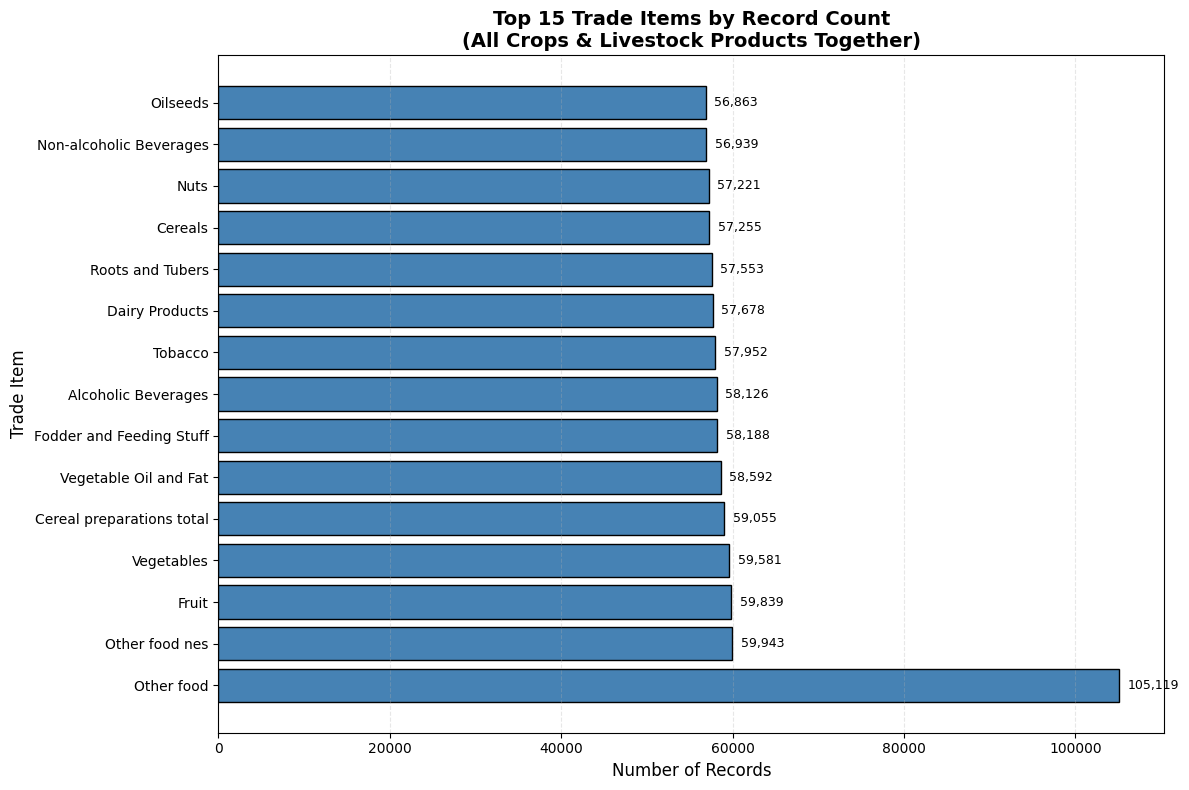


SUMMARY STATISTICS
Total Distinct Items: 616
Total Records: 17,270,631
Average Records per Item: 28,036.7

Most frequent item: Other food (105,119 records)
Least frequent item: Other raw skins of other animals, fresh (70 records)


In [75]:
# EDA 1: TOTAL TRADE ITEMS (ALL PRODUCTS TOGETHER - RECORD COUNTS ONLY)
print("\n" + "=" * 60)
print("EDA 1: COUNT FOR EACH TRADE ITEM (ALL PRODUCTS)")
print("=" * 60)

# Show total distinct trade items
distinct_items = df_before.select("Item").distinct().count()
print(f"\n📊 TOTAL DISTINCT TRADE ITEMS: {distinct_items:,}")
print(f"📊 TOTAL RECORDS: {df_before.count():,}")

# Count for each trade item (ALL items together) - NO VALUE
item_counts_before = df_before.groupBy("Item").agg(
    F.count("*").alias("Record_Count")
).orderBy(F.desc("Record_Count"))

print("\n📊 TOP 20 ITEMS BY RECORD COUNT (ALL PRODUCTS TOGETHER):")
item_counts_before.show(20, truncate=False)

# Collect for visualization (top 15 for better view)
item_top_list = item_counts_before.limit(15).collect()
items_top = [row.Item for row in item_top_list]
counts_top = [row.Record_Count for row in item_top_list]

# VISUALIZATION
plt.figure(figsize=(12, 8))

plt.barh(items_top, counts_top, color='steelblue', edgecolor='black')
plt.title('Top 15 Trade Items by Record Count\n(All Crops & Livestock Products Together)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Trade Item', fontsize=12)

# Add value labels
for i, v in enumerate(counts_top):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Simple summary
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total Distinct Items: {distinct_items:,}")
print(f"Total Records: {df_before.count():,}")
print(f"Average Records per Item: {df_before.count() / distinct_items:,.1f}")

# Most and least frequent items
print(f"\nMost frequent item: {item_counts_before.first()['Item']} ({item_counts_before.first()['Record_Count']:,} records)")
least_frequent = item_counts_before.orderBy(F.asc("Record_Count")).filter(F.col("Record_Count") > 0).first()
print(f"Least frequent item: {least_frequent['Item']} ({least_frequent['Record_Count']:,} records)")